# S&P 500 Returns and U.S. Macroeconomic Indicators — Exploratory Analysis

**Objective:** Conduct an exploratory data analysis of the time series via histograms and Q-Q plots  to detect early signs of non-stationarity.

## 1. Load the Cleaned Dataset

In [13]:
%pip install scipy
import pandas as pd
import os
os.makedirs("images", exist_ok=True)

df = pd.read_csv("sp500_macro_monthly_1990_2026.csv",index_col=0,parse_dates=True)
print(df.shape)
print(df.head())

Note: you may need to restart the kernel to use updated packages.
(426, 9)
            unemployment_rate  fed_rate   indpro  gs10  usrec  sp500_close  \
1991-01-01                6.4      6.91  61.1355  8.09    1.0   343.929993   
1991-02-01                6.6      6.25  60.6838  7.85    1.0   367.070007   
1991-03-01                6.8      6.12  60.3346  8.11    1.0   375.220001   
1991-04-01                6.7      5.91  60.4938  8.04    0.0   375.339996   
1991-05-01                6.9      5.78  61.0633  8.07    0.0   389.829987   

            inflation_yoy  sp500_log_return  log_indpro  
1991-01-01       5.647059          4.067902    4.113093  
1991-02-01       5.312500          6.511446    4.105677  
1991-03-01       4.821151          2.195994    4.099906  
1991-04-01       4.809930          0.031975    4.102541  
1991-05-01       5.034857          3.787844    4.111911  



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Descriptive Statistics 

In [14]:
df.describe()

,unemployment_rate,fed_rate,indpro,gs10,usrec,sp500_close,inflation_yoy,sp500_log_return,log_indpro
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,5.656690,2.742887,91.277873,4.130446,0.072770,1942.875160,2.632942,0.733055,4.503811
std,1.759374,2.187730,12.137910,1.808812,0.260064,1568.372328,1.538167,4.257658,0.147269
min,3.400000,0.050000,60.334600,0.620000,0.000000,343.929993,-1.958761,-18.563647,4.099906
25%,4.300000,0.212500,87.714525,2.580000,0.000000,982.080017,1.725929,-1.742091,4.474086
50%,5.250000,2.495000,95.868450,4.135000,0.000000,1324.264954,2.595164,1.209956,4.562977
75%,6.600000,5.067500,100.466050,5.490000,0.000000,2471.312439,3.179038,3.454873,4.609820
max,14.800000,6.910000,104.100400,8.280000,1.000000,7580.060059,8.979361,11.942084,4.645356


In [15]:
# check that the dummy variable for recession only show values between 0 and 1
print(df['usrec'].value_counts())

usrec
0.0    395
1.0     31
Name: count, dtype: int64


## 3. Time Series Plots

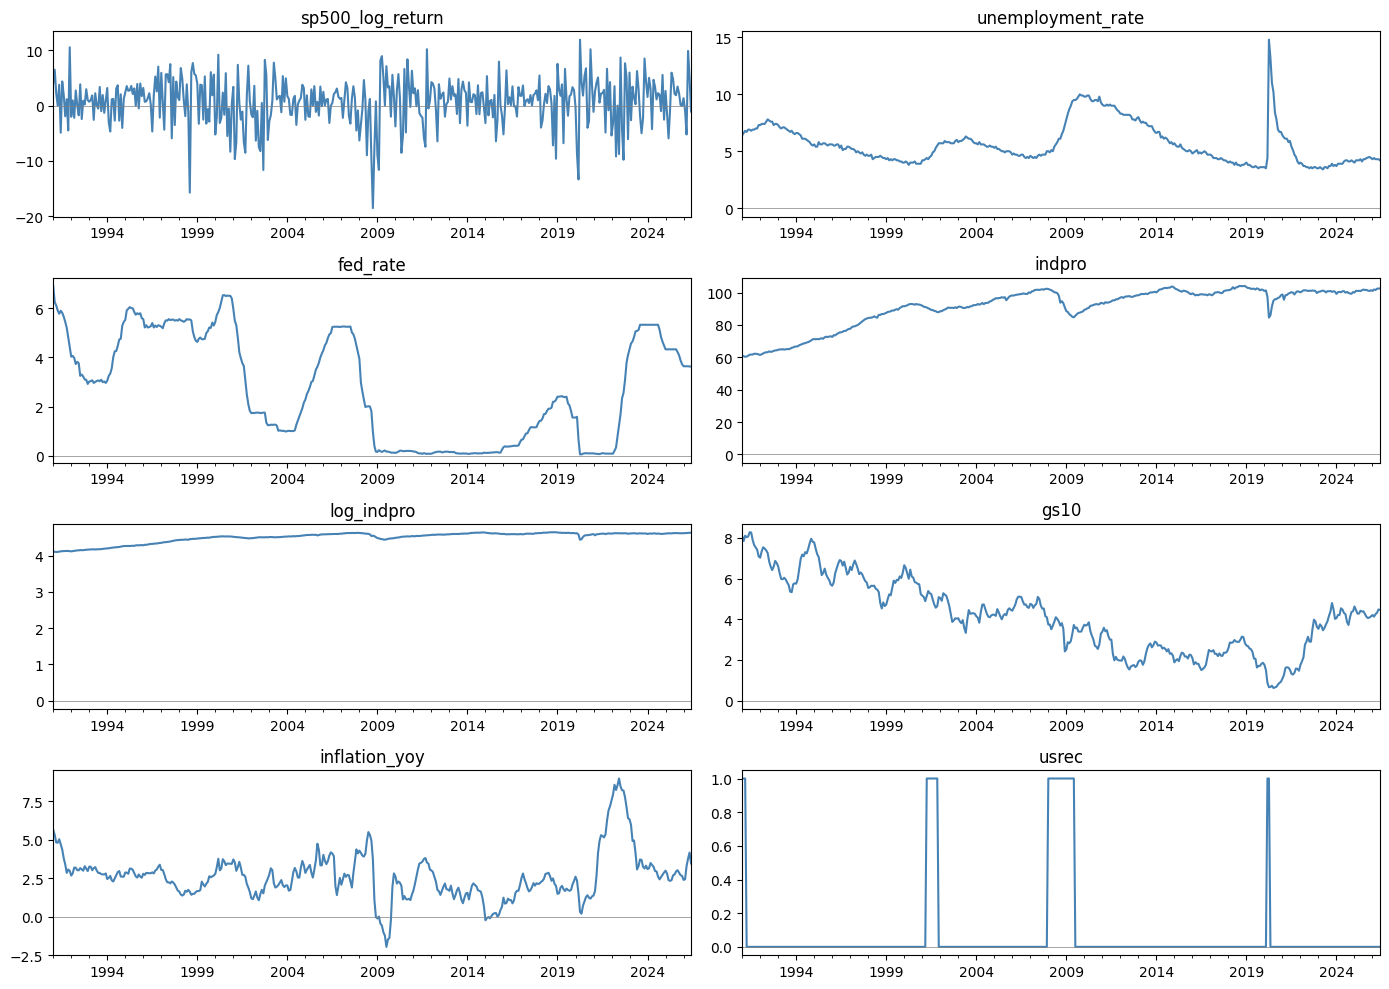

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize = (14,10))
cols = ['sp500_log_return', 'unemployment_rate', 'fed_rate', 'indpro', 'log_indpro', 'gs10', 'inflation_yoy', 'usrec']

for ax, col in zip(axes.flat, cols):
    df[col].plot(ax=ax, title=col, color = 'steelblue')
    ax.axhline(0, color='gray', linewidth=0.5)

for ax in axes.flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('images/time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()



## 4. Distributions

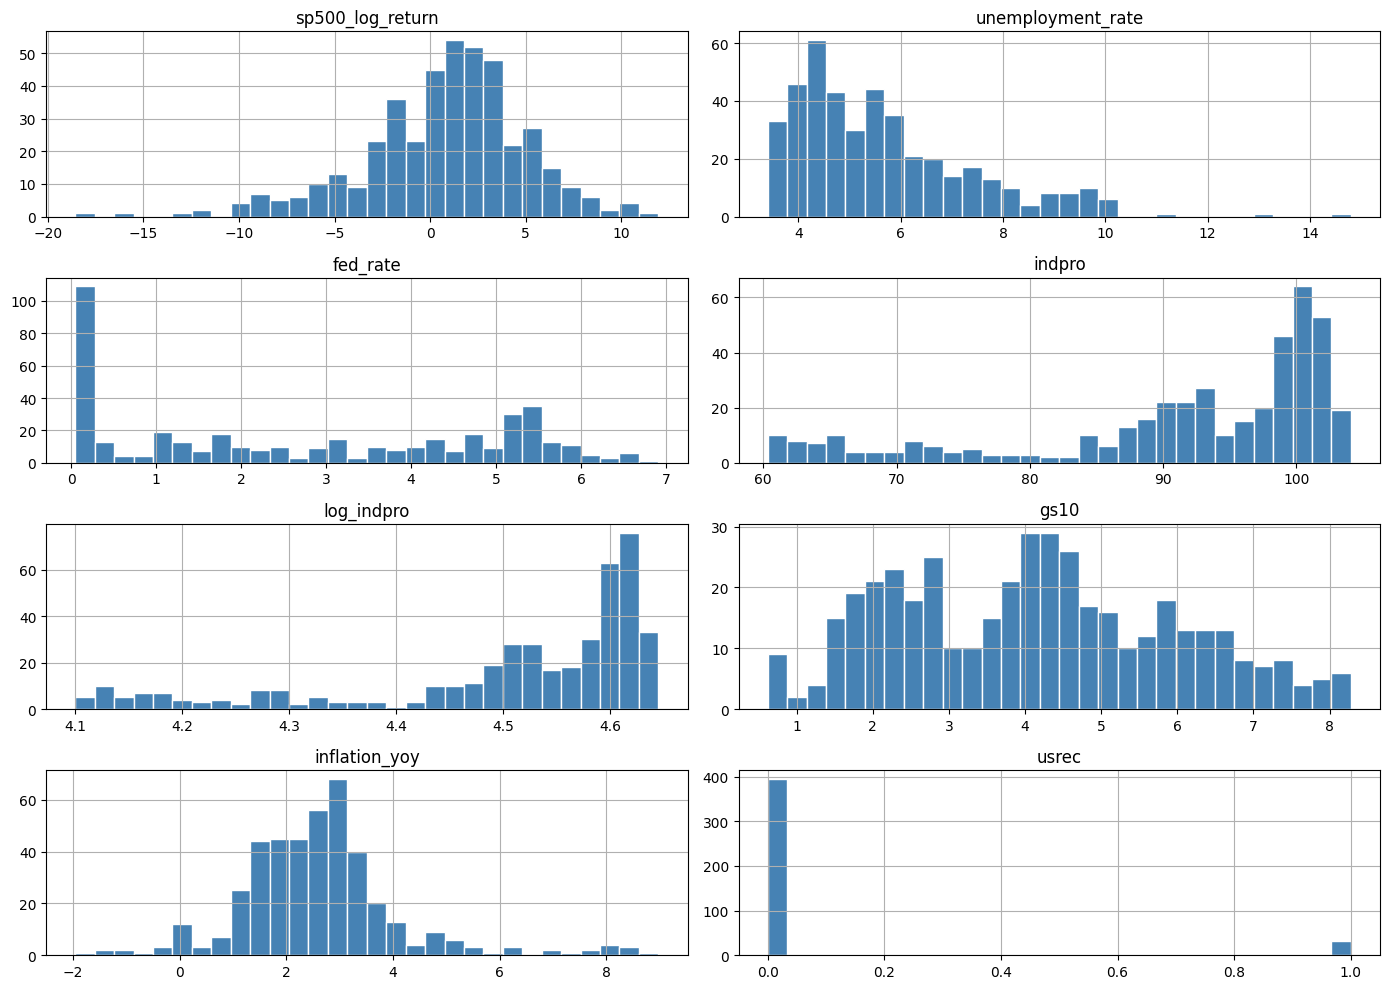

In [17]:
fig, axes = plt.subplots(4,2, figsize = (14,10))
cols = ['sp500_log_return', 'unemployment_rate', 'fed_rate', 'indpro', 'log_indpro', 'gs10', 'inflation_yoy', 'usrec']

for ax, col in zip(axes.flat, cols):
    df[col].hist(ax=ax, bins=30, color = 'steelblue',edgecolor='white')
    ax.set_title(col)

for ax in axes.flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('images/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Q-Q Plots (Normality Check)

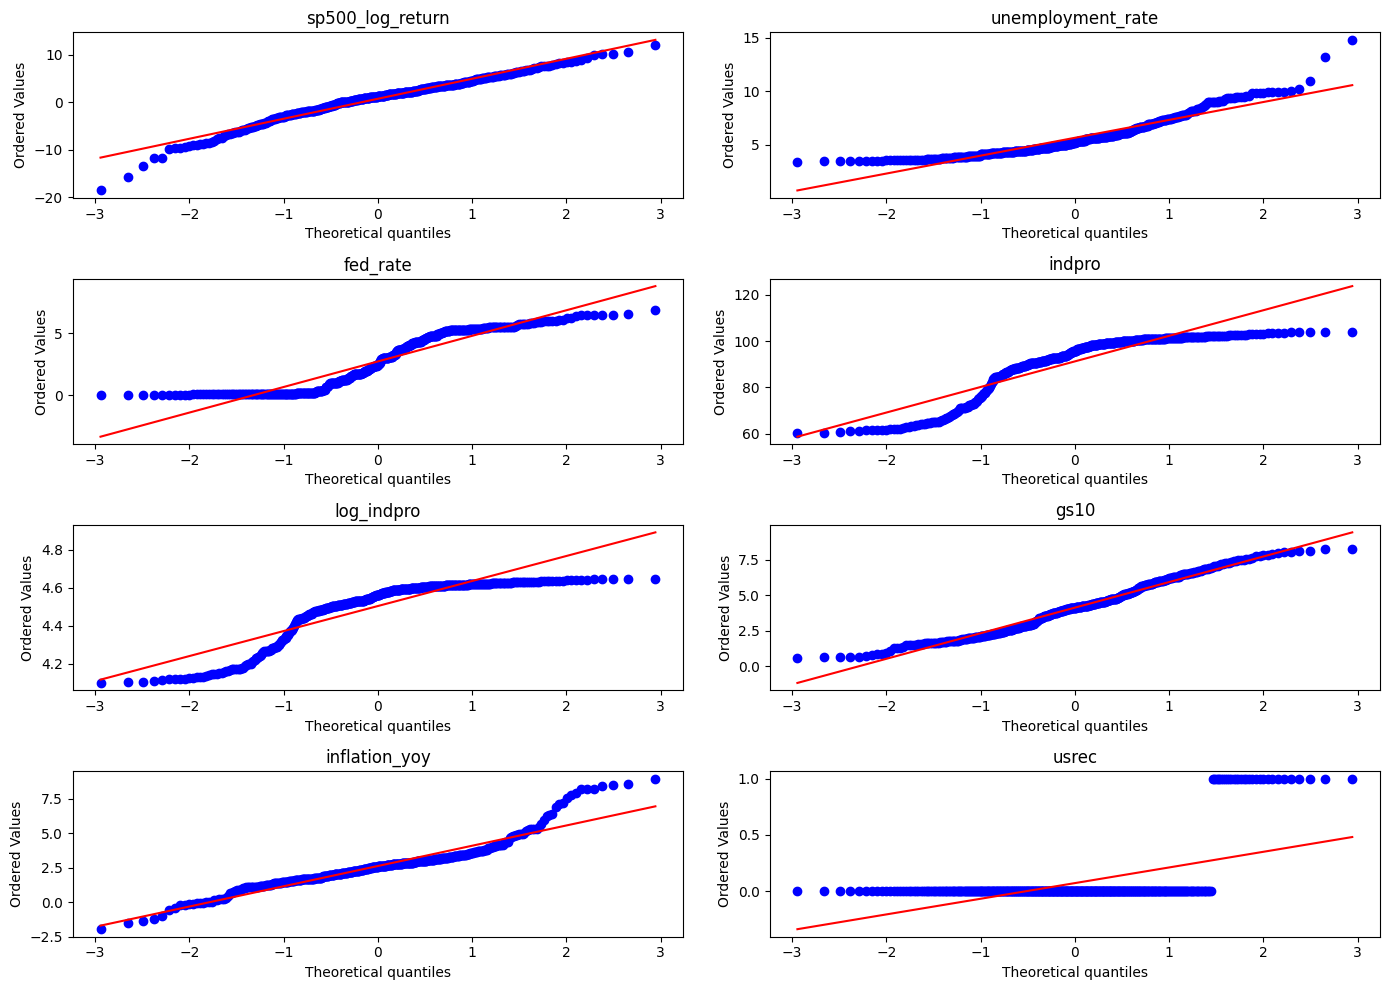

In [18]:
import scipy.stats as stats

fig, axes = plt.subplots(4,2, figsize = (14,10))
cols = ['sp500_log_return', 'unemployment_rate', 'fed_rate', 'indpro', 'log_indpro', 'gs10', 'inflation_yoy', 'usrec']

for ax, col in zip(axes.flat, cols):
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(col)

for ax in axes.flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('images/qq_plots.png', dpi=150,bbox_inches='tight')
plt.show()